1. Importaciones y configuración inicial

In [1]:
import pandas as pd
import os

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sns.set_theme(style="ticks", palette="colorblind")
#Para modelo regresión lineal múltiple:
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
#Para Random Forest:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
#Para Permutation Importance:
from sklearn.inspection import permutation_importance
#Para crear gráficos de dependencia parcial:
from sklearn.inspection import PartialDependenceDisplay
#Para visualización de un árbol individual:
from sklearn.tree import plot_tree
#Para SHAP Summary Plot:
import shap

ruta_carpeta_csv = r"C:\Users\misab\Documents\IT Academy\Especialitzacio\sprint 13\notebooks\data\processed"

carpeta = "graficos"
os.makedirs(carpeta, exist_ok=True)

2. Importar csv

In [2]:
df_visual = pd.read_csv(os.path.join(ruta_carpeta_csv, "df_graficos.csv"))

df_visual

,country_code,country_name,year,variable,valor
0,AT,Austria,2014,gini,27.6
1,AT,Austria,2015,gini,27.2
2,AT,Austria,2016,gini,27.2
3,AT,Austria,2017,gini,27.9
4,AT,Austria,2018,gini,26.8
...,...,...,...,...,...
1535,SK,Slovakia,2020,inflation_rate,2.0
1536,SK,Slovakia,2021,inflation_rate,2.8
1537,SK,Slovakia,2022,inflation_rate,12.1
1538,SK,Slovakia,2023,inflation_rate,11.0


3. Exploración inicial

In [3]:
print(df_visual.info())
print("\nValores nulos por dimensión:")
print(df_visual.isna().sum())
print("\nInformación sobre países:")
q_paises = df_visual["country_name"].nunique()
n_paises = df_visual["country_name"].unique().tolist()
print(f"Hay un total de {q_paises} paises que son los siguientes:\n{n_paises}")
print("\nInformación sobre años:")
q_anos = df_visual["year"].nunique()
n_anos = df_visual["year"].unique().tolist()
print(f"Hay un total de {q_anos} años que son los siguientes:\n{n_anos}")
print("\nInformación sobre variables:")
q_var = df_visual["variable"].nunique()
n_var = df_visual["variable"].unique().tolist()
print(f"Hay un total de {q_var} variables que son las siguientes:\n{n_var}")


<class 'pandas.DataFrame'>
RangeIndex: 1540 entries, 0 to 1539
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  1540 non-null   str    
 1   country_name  1540 non-null   str    
 2   year          1540 non-null   int64  
 3   variable      1540 non-null   str    
 4   valor         1540 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 60.3 KB
None

Valores nulos por dimensión:
country_code    0
country_name    0
year            0
variable        0
valor           0
dtype: int64

Información sobre países:
Hay un total de 20 paises que son los siguientes:
['Austria', 'Belgium', 'Cyprus', 'Germany', 'Estonia', 'Greece', 'Spain', 'Finland', 'France', 'Croatia', 'Ireland', 'Italy', 'Lithuania', 'Luxembourg', 'Latvia', 'Malta', 'Netherlands', 'Portugal', 'Slovenia', 'Slovakia']

Información sobre años:
Hay un total de 11 años que son los siguientes:
[2014, 2015, 2016, 2017, 2018, 201

4. Función guardar gráficos

In [4]:
contador_graficos = 1

def guardar_grafico(fig, nombre):
    """
    Guarda gráficos en la carpeta 'graficos' con numeración automática.
    Input: Figura y nombre que se le quiere dar al gáfico.
    Output: Png del gráfico guardado en carpeta seleccionada.
    """
    global contador_graficos
    
    nombre_archivo = f"{contador_graficos:02d}_{nombre}.png"
    ruta = f"graficos/{nombre_archivo}"
    
    fig.savefig(ruta, dpi=300, bbox_inches="tight")
    print("Guardado con éxito.")
    
    contador_graficos += 1

5. Visualizaciones descriptivas

Guardado con éxito.


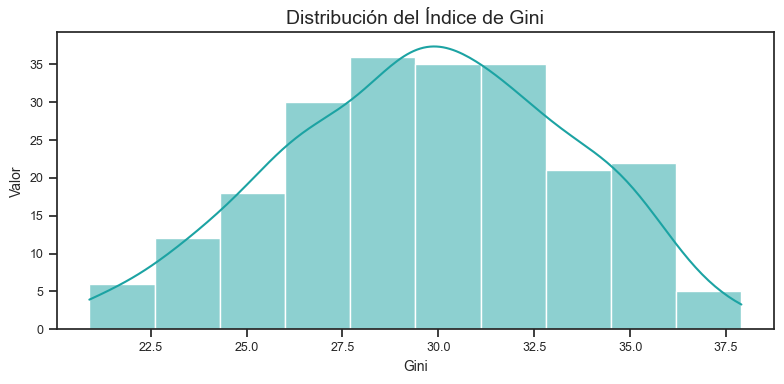

In [5]:
#Distribución del Índice de Gini:
plt.figure(figsize=(8,4))

sns.histplot(df_visual[df_visual["variable"]=="gini"]["valor"], kde=True, color="#1CA3A3")

titulo = "Distribución del Índice de Gini"
plt.title(titulo, fontsize=14)
plt.xlabel("Gini", fontsize=10)
plt.ylabel("Valor", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


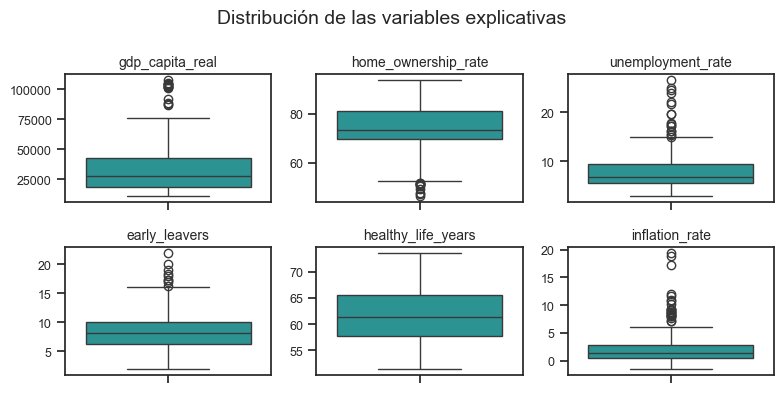

In [6]:
#Distribución de las variables explicativas:
vars_exp = ["gdp_capita_real",
            "home_ownership_rate",
            "unemployment_rate",
            "early_leavers",
            "healthy_life_years",
            "inflation_rate"]

plt.figure(figsize=(8,4))

for i, var in enumerate(vars_exp, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_visual[df_visual["variable"] == var],y="valor",color="#1CA3A3")
    plt.title(var, fontsize=10)
    plt.xlabel("")
    plt.ylabel("")
    plt.tick_params(axis='both', labelsize=9)
titulo = "Distribución de las variables explicativas"
plt.suptitle(titulo, fontsize=14)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


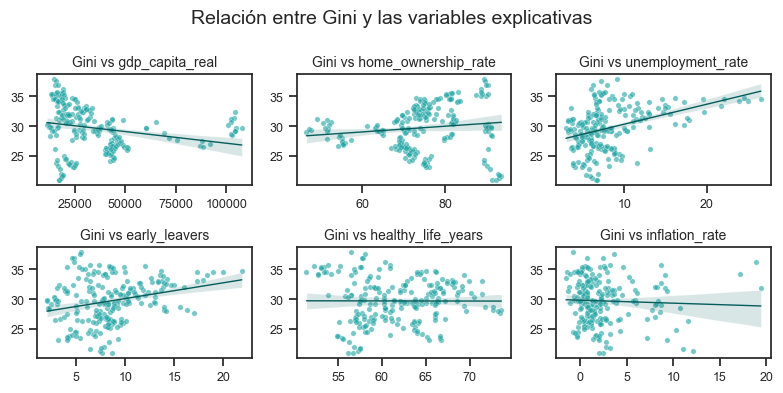

In [7]:
#Visualizar correlaciones de las variables explicativas con Índice de Gini:
df_corr = df_visual.pivot_table(index=["country_code", "country_name", "year"],columns="variable",values="valor").reset_index()

plt.figure(figsize=(8,4))

for i, var in enumerate(vars_exp, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=df_corr, x=var, y="gini", alpha=0.6, color="#1CA3A3", s=15)
    sns.regplot(data=df_corr,x=var,y="gini",scatter=False,color="#045C5C",line_kws={"linewidth":1})
    plt.title(f"Gini vs {var}", fontsize=10)
    plt.xlabel("")
    plt.ylabel("")
    plt.tick_params(axis='both', labelsize=9)
titulo = "Relación entre Gini y las variables explicativas"
plt.suptitle(titulo, fontsize=14)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


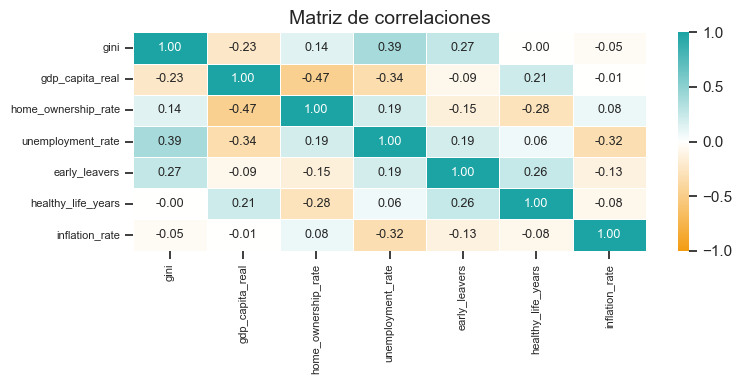

In [8]:
# Heatmap de correlaciones entre Gini y las variables explicativas
columnas = ["gini"] + vars_exp
correlaciones = df_corr[columnas].corr()

plt.figure(figsize=(8,4))

# Paleta personalizada:
colors = ["#F39C12","white", "#1CA3A3"]
OrWhGn = LinearSegmentedColormap.from_list("OrWhGn", colors)

sns.heatmap(correlaciones, annot=True, cmap= OrWhGn, fmt=".2f", linewidths=0.5, annot_kws={"fontsize":9}, vmin=-1, vmax=1, center = 0)

titulo = "Matriz de correlaciones"
plt.title(titulo, fontsize=14)
plt.xlabel("")
plt.ylabel("")
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


<Figure size 800x400 with 0 Axes>

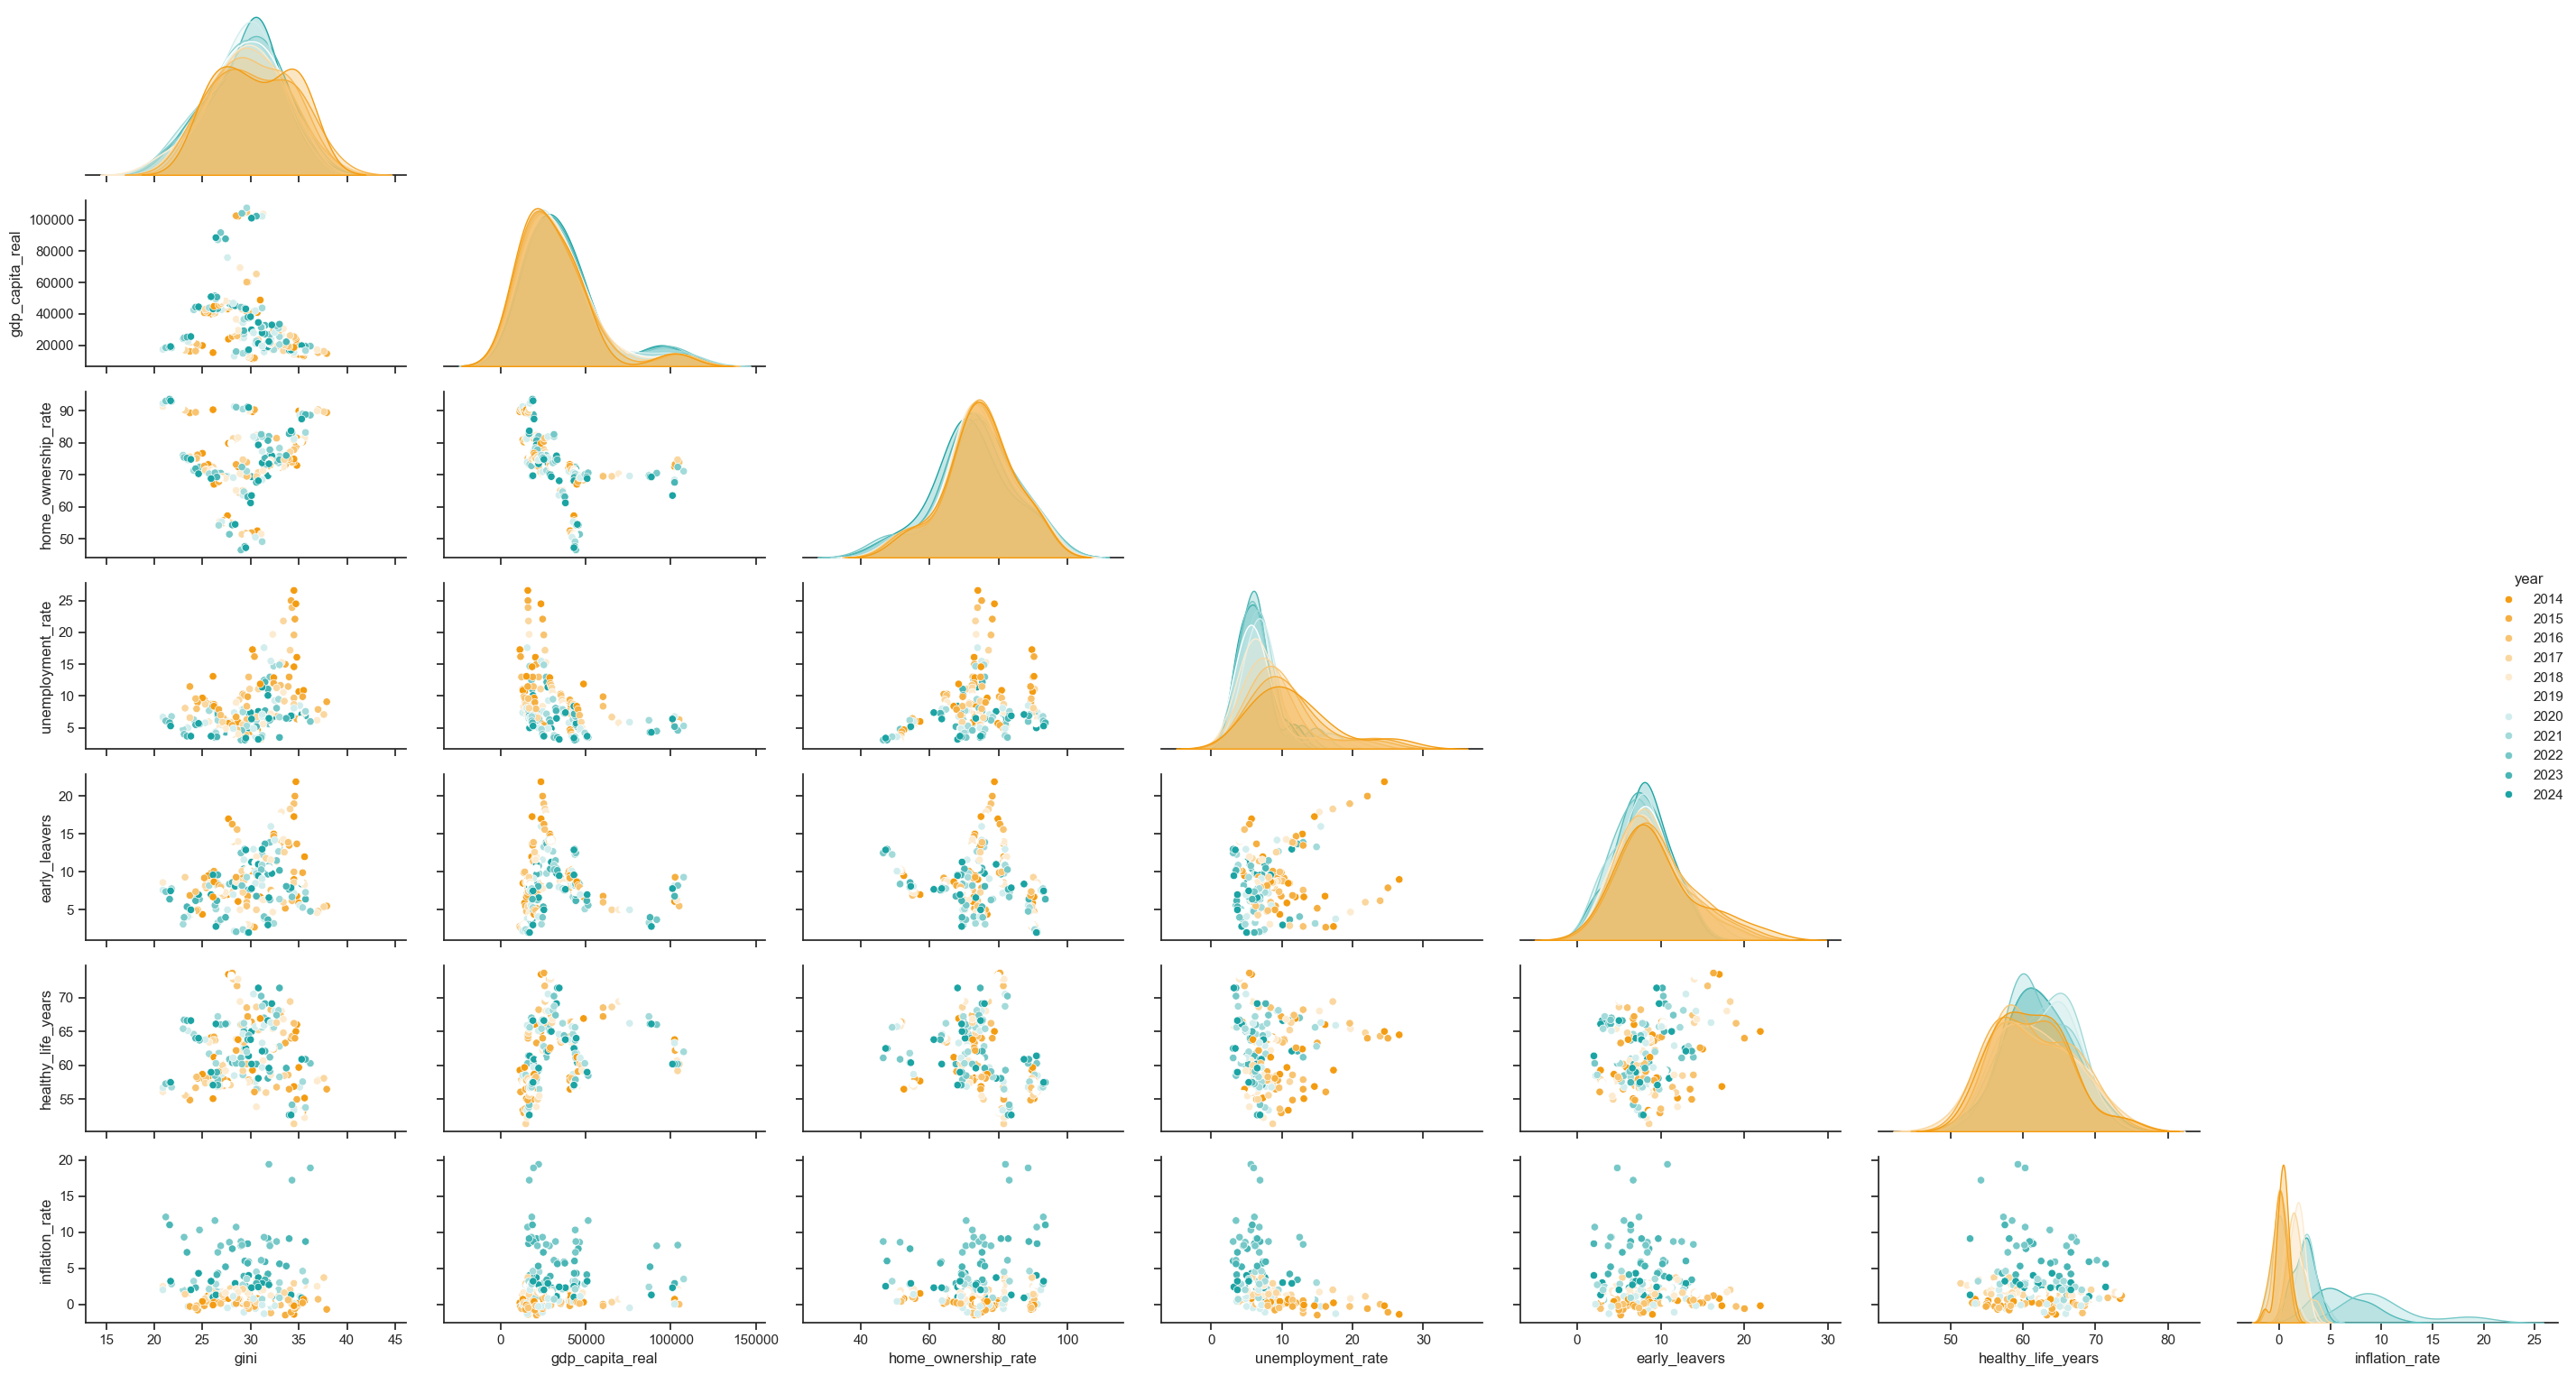

In [9]:
#Pairplot
variables = ["gini"] + vars_exp
years = sorted(df_corr['year'].unique())
palette = [OrWhGn(i) for i in np.linspace(0, 1, len(years))]

plt.figure(figsize=(8,4))
sns.pairplot(df_corr, hue='year', vars=variables, palette=palette, corner = True, height=2.2, aspect=1.8 )

titulo = "Pairplot variables"

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


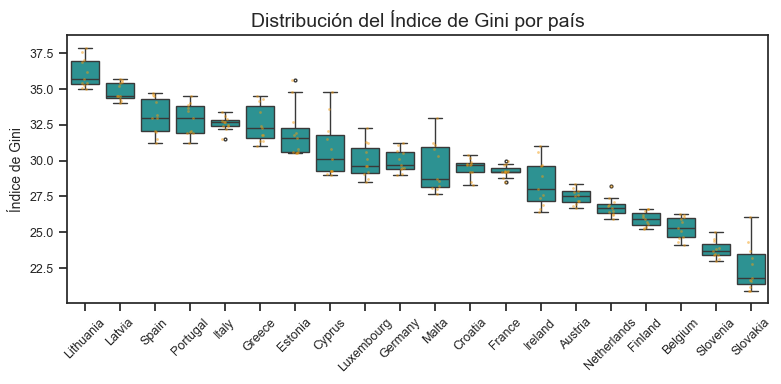

In [10]:
#Boxplots del Índice de Gini por país
order = df_corr.groupby("country_name")["gini"].mean().sort_values(ascending=False).index

plt.figure(figsize=(8,4))

sns.boxplot(data=df_corr, x="country_name",y="gini", order=order, color="#1CA3A3", fliersize=2)
sns.stripplot(data=df_corr, x="country_name",y="gini", order=order, color="#F39C12", alpha=0.5, size=2)

titulo = "Distribución del Índice de Gini por país"
plt.title(titulo, fontsize=14)
plt.xlabel("")
plt.ylabel("Índice de Gini", fontsize=10)
plt.xticks(fontsize=9, rotation=45)
plt.yticks(fontsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


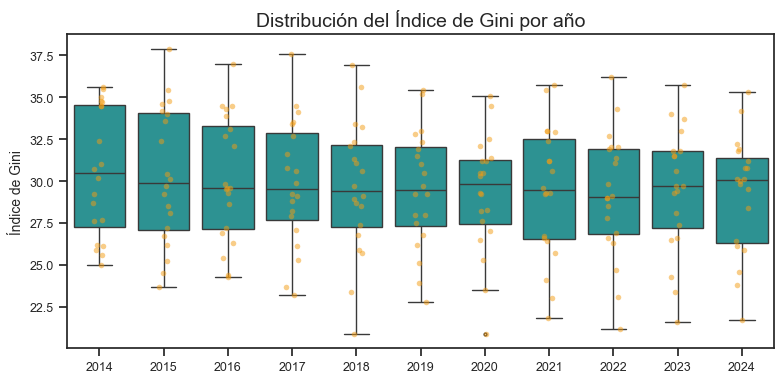

In [11]:
#Boxplots del Índice de Gini por año
plt.figure(figsize=(8,4))

sns.boxplot(data=df_corr,x="year",y="gini", color="#1CA3A3", fliersize=2)
sns.stripplot(data=df_corr,x="year",y="gini",color="#F39C12",alpha=0.5,size=4)

titulo = "Distribución del Índice de Gini por año"
plt.title(titulo, fontsize=14)
plt.xlabel("")
plt.ylabel("Índice de Gini", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


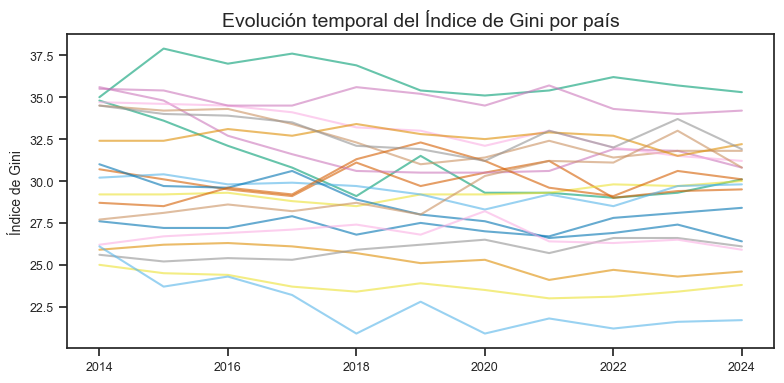

In [12]:
#Evolución temporal del Gini por país
plt.figure(figsize=(8,4))

for country in df_corr["country_name"].unique():
    df_temp = df_corr[df_corr["country_name"] == country]
    plt.plot(df_temp["year"], df_temp["gini"], alpha=0.6)

titulo = "Evolución temporal del Índice de Gini por país"
plt.title(titulo, fontsize=14)
plt.xlabel("")
plt.ylabel("Índice de Gini", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


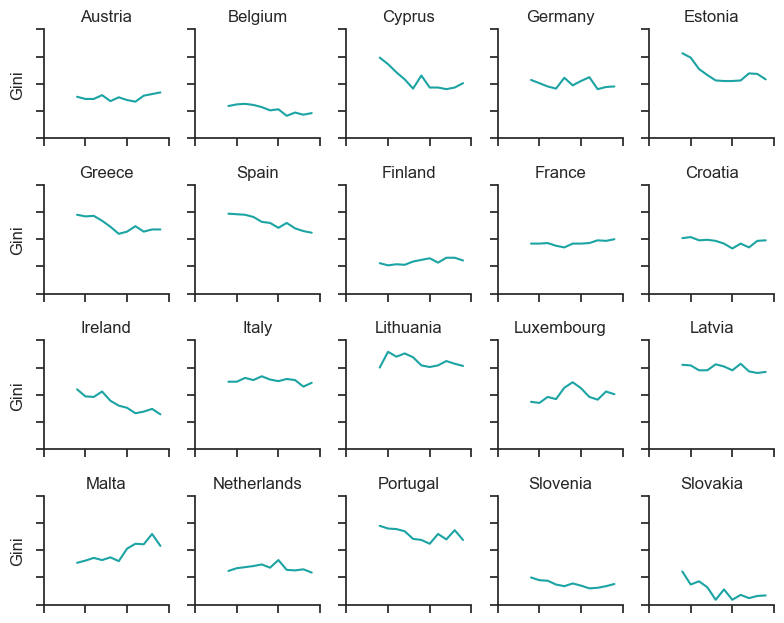

In [13]:
#Gini por país por separado
g = sns.FacetGrid(df_corr, col="country_name", col_wrap=5, height=1.6)
g.map_dataframe(sns.lineplot, x="year", y="gini", color="#1CA3A3")
g.set_titles("{col_name}")
g.set_axis_labels("", "Gini")
g.set_xticklabels(fontsize=6)
g.set_yticklabels(fontsize=6)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


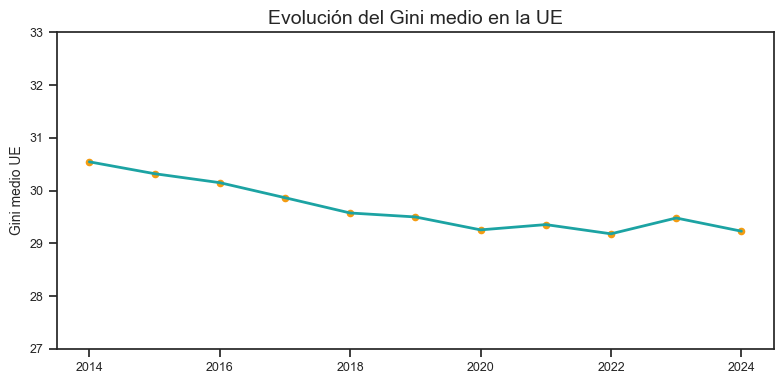

In [14]:
#Evolución temporal del Gini agregado (media Zona Euro)
df_mean = df_corr.groupby("year")["gini"].mean().reset_index()

plt.figure(figsize=(8,4))

plt.plot(df_mean["year"], df_mean["gini"], color="#1CA3A3", linewidth=2)
plt.scatter(df_mean["year"], df_mean["gini"], color="#F39C12", s=20)

titulo = "Evolución del Gini medio en la UE"
plt.title(titulo, fontsize=14)
plt.xlabel("")
plt.ylabel("Gini medio UE", fontsize=10)
plt.tick_params(axis='both', labelsize=9)
plt.ylim(27, 33)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


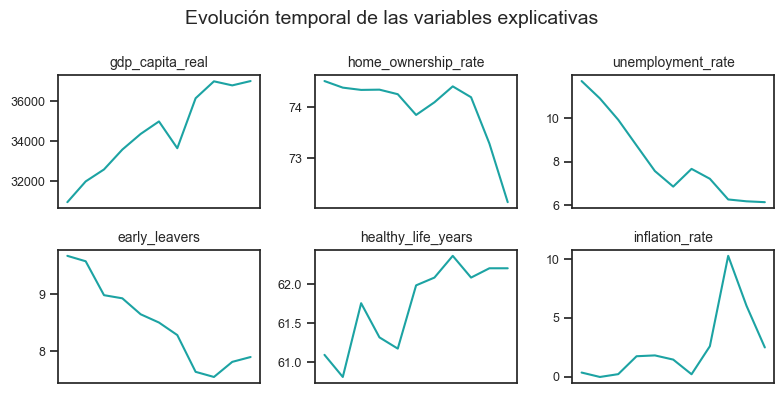

In [15]:
#Evolución temporal de las variables explicativas
plt.figure(figsize=(8,4))

for i, var in enumerate(vars_exp, 1):
    plt.subplot(2, 3, i)
    df_temp = df_corr.groupby("year")[var].mean().reset_index()
    plt.plot(df_temp["year"], df_temp[var], color="#1CA3A3", linewidth=1.5)
    plt.title(var, fontsize=10)
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks([])
    plt.yticks(fontsize=9)
titulo = "Evolución temporal de las variables explicativas"
plt.suptitle(titulo, fontsize=14)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


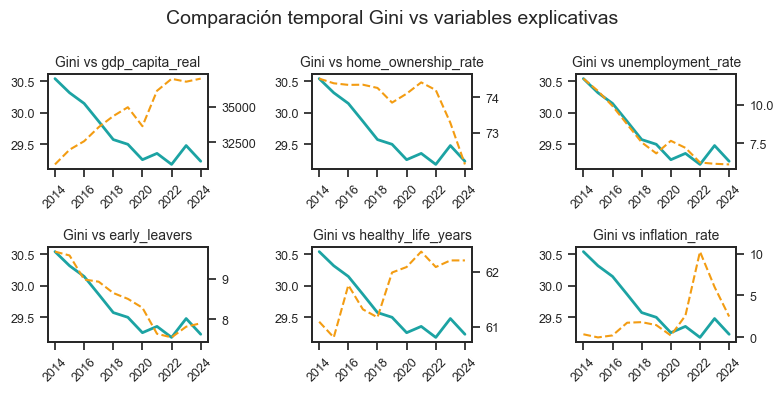

In [16]:
#Comparación temporal Gini vs variables explicativas
fig, axes = plt.subplots(2, 3, figsize=(8, 4))

for ax1, var in zip(axes.flatten(), vars_exp):
    #Gini
    df_gini = df_corr.groupby("year")["gini"].mean().reset_index()
    ax1.plot(df_gini["year"], df_gini["gini"], color="#1CA3A3", linewidth=2, label="Gini")
    ax1.tick_params(axis='y', labelsize=9)
    years = sorted(df_gini["year"].unique())
    ax1.set_xticks(years[::2])
    ax1.set_xticklabels(years[::2], rotation=45, fontsize=9)

    #Variable
    df_var = df_corr.groupby("year")[var].mean().reset_index()
    ax2 = ax1.twinx()
    ax2.plot(df_var["year"], df_var[var], color="#F39C12", linewidth=1.5, linestyle="--", label=var)
    ax2.tick_params(axis='y', labelsize=9)

    ax1.set_title(f"Gini vs {var}", fontsize=10)

titulo = "Comparación temporal Gini vs variables explicativas"
fig.suptitle(titulo, fontsize=14)

fig.tight_layout()
guardar_grafico(fig,titulo)
plt.show()

6. Visualizaciones modelo regresión lineal múltiple

In [17]:
#Modelo regresión lineal múltiple
variables = ['gini','home_ownership_rate','unemployment_rate','early_leavers','healthy_life_years','gdp_capita_real','inflation_rate']
#Crear un df para el modelo:
df_modelo = df_corr[variables].copy()
df_modelo.head()

#Crear variables transformadas para corregir asimetría en base a resultados anteriores:
df_modelo["log_unemployment"] = np.log(df_modelo["unemployment_rate"])
df_modelo["log_gdp"] = np.log(df_modelo["gdp_capita_real"])
df_modelo["sqrt_early_leavers"] = np.sqrt(df_modelo["early_leavers"])
df_modelo.head()

#Definir variable dependiente (y) e independientes (x):
y = df_modelo["gini"]

x = df_modelo[[
    "home_ownership_rate",
    "log_unemployment",
    "sqrt_early_leavers",
    "healthy_life_years",
    "log_gdp",
    "inflation_rate"]]

#Crear y entrenar modelo:
modelo = LinearRegression()
modelo.fit(x, y)

pendientes = modelo.coef_
interseccion = modelo.intercept_

print("Pendientes (coeficientes) de cada variable en el orden de x.columns:")
for var, coef in zip(x.columns, pendientes):
    print(f"  - {var}: {round(coef, 4)}")
print(f"\nIntersección (término constante): {round(interseccion, 4)}")

#Coeficiente de calidad:
#“Qué porcentaje de la variabilidad de Gini explican TODAS las variables juntas”.
coef_R2 = modelo.score(x, y)
print(f"El coeficiente R² es de {round(coef_R2, 2)}, el modelo explica el {round(coef_R2*100, 2)}% de la variabilidad del Índice de Gini.")


Pendientes (coeficientes) de cada variable en el orden de x.columns:
  - home_ownership_rate: -0.0216
  - log_unemployment: 2.4772
  - sqrt_early_leavers: 1.3107
  - healthy_life_years: 0.0215
  - log_gdp: -1.7483
  - inflation_rate: 0.1015

Intersección (término constante): 39.0482
El coeficiente R² es de 0.23, el modelo explica el 23.48% de la variabilidad del Índice de Gini.


Guardado con éxito.


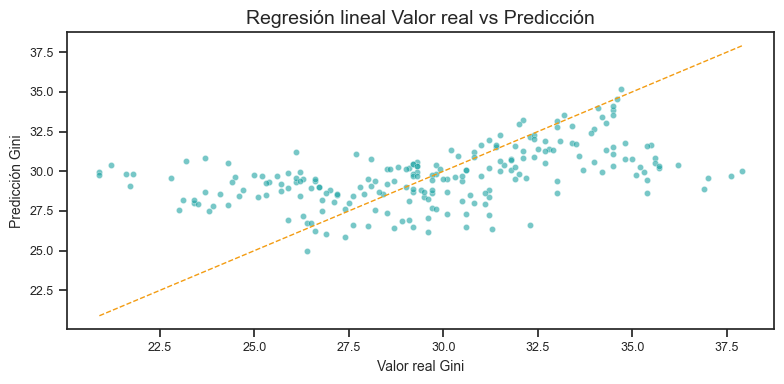

In [18]:
# Predicciones del modelo
y_pred = modelo.predict(x)
y_real = y

plt.figure(figsize=(8,4))
sns.scatterplot(x=y_real, y=y_pred, color="#1CA3A3", alpha=0.6, s=20)

#Línea de referencia (perfecta predicción)
min_val = min(y_real.min(), y_pred.min())
max_val = max(y_real.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="#F39C12", linestyle="--", linewidth=1)

titulo = "Regresión lineal Valor real vs Predicción"
plt.title(titulo, fontsize=14)
plt.xlabel("Valor real Gini", fontsize=10)
plt.ylabel("Predicción Gini", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


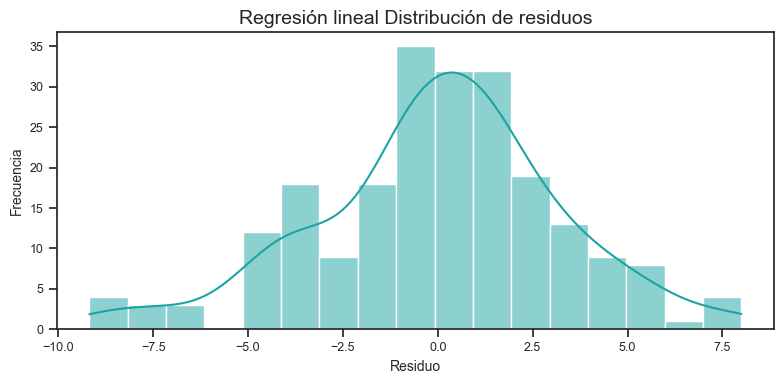

In [19]:
#Distribución de residuos
residuals = y_real - y_pred

plt.figure(figsize=(8,4))
sns.histplot(residuals, kde=True, color="#1CA3A3")

titulo = "Regresión lineal Distribución de residuos"
plt.title(titulo, fontsize=14)
plt.xlabel("Residuo", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


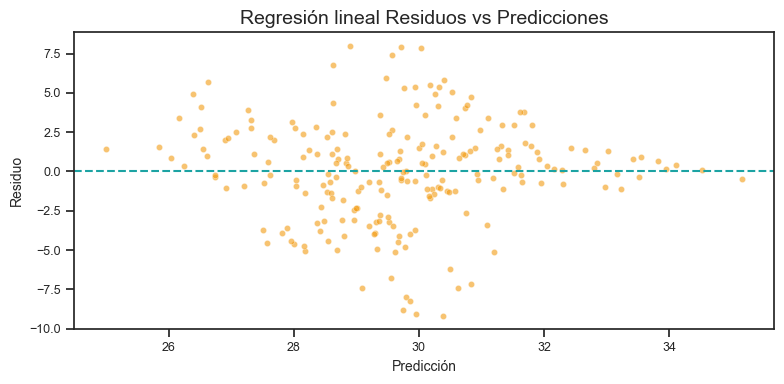

In [20]:
#Residuos vs Predicciones
plt.figure(figsize=(8,4))

sns.scatterplot(x=y_pred, y=residuals, color="#F39C12", alpha=0.6, s=20)
plt.axhline(0, color="#1CA3A3", linestyle="--")

titulo = "Regresión lineal Residuos vs Predicciones"
plt.title(titulo, fontsize=14)
plt.xlabel("Predicción", fontsize=10)
plt.ylabel("Residuo", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


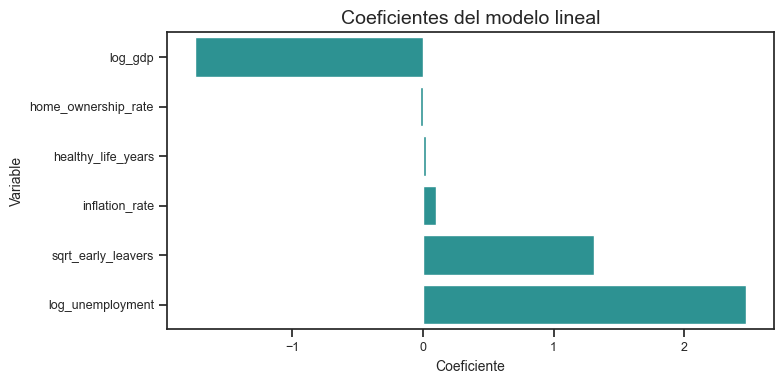

In [21]:
#Importancia de coeficientes
coef_df = pd.DataFrame({"variable": x.columns, "coef": modelo.coef_}).sort_values("coef")

plt.figure(figsize=(8,4))
sns.barplot(data=coef_df, x="coef", y="variable", color="#1CA3A3")

titulo = "Coeficientes del modelo lineal"
plt.title(titulo, fontsize=14)
plt.xlabel("Coeficiente", fontsize=10)
plt.ylabel("Variable", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

In [22]:
#Estandarización de variables
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns, index=x.index)

modelo_scaled = LinearRegression()
modelo_scaled.fit(x_scaled, y)

coef_scaled = modelo_scaled.coef_

Guardado con éxito.


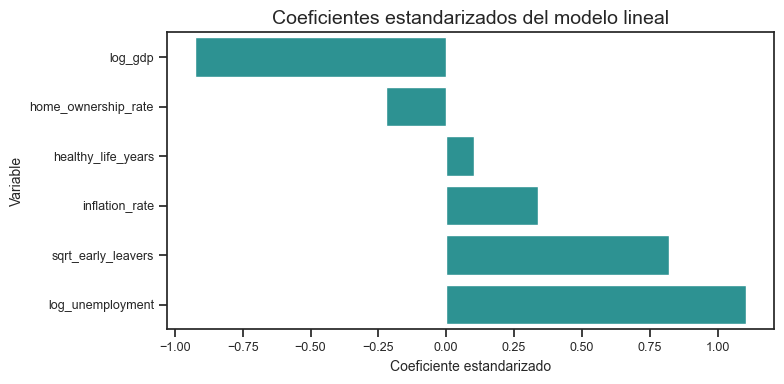

In [23]:
#Importancias estandarizadas
coef_df_scaled = pd.DataFrame({"variable": x.columns,
                               "coef": coef_scaled}).sort_values("coef")

plt.figure(figsize=(8,4))
sns.barplot(data=coef_df_scaled, x="coef", y="variable", color="#1CA3A3")

titulo = "Coeficientes estandarizados del modelo lineal"
plt.title(titulo, fontsize=14)
plt.xlabel("Coeficiente estandarizado", fontsize=10)
plt.ylabel("Variable", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

7. Visualizaciones Random Forest

In [24]:
#Modelo final Random forest:
y = df_modelo["gini"]
x = df_modelo[[
    'home_ownership_rate',
    'unemployment_rate',
    'early_leavers',
    'healthy_life_years',
    'gdp_capita_real',
    'inflation_rate']]

#Separar en train y test:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
#Crear el modelo Random Forest:
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=12,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42)
#Entrenar el modelo:
rf.fit(x_train, y_train)
#Hacer predicciones en el conjunto de test:
y_pred_rf = rf.predict(x_test)
#Evaluar el modelo: R² y RMSE:
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print(f"R² Random Forest (test): {round(r2_rf, 4)}")
print(f"RMSE Random Forest (test): {round(rmse_rf, 4)}")
#Ver la importancia de las variables:
importancias = pd.Series(rf.feature_importances_, index=x.columns)
importancias.sort_values(ascending=False, inplace=True)
print(importancias)

R² Random Forest (test): 0.5909
RMSE Random Forest (test): 2.3542
variable
gdp_capita_real        0.276246
home_ownership_rate    0.249529
early_leavers          0.182717
unemployment_rate      0.173867
healthy_life_years     0.088916
inflation_rate         0.028725
dtype: float64


Guardado con éxito.


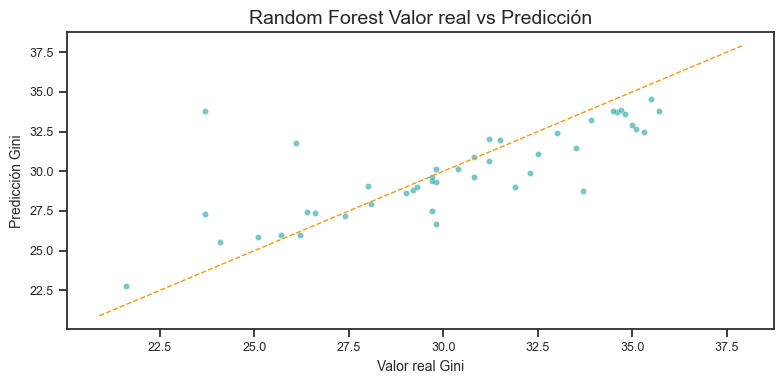

In [25]:
#Real vs predicción
plt.figure(figsize=(8,4))

sns.scatterplot(x=y_test, y=y_pred_rf, color="#1CA3A3", alpha=0.6, s=20)

min_val = min(y_real.min(), y_pred.min())
max_val = max(y_real.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="#F39C12", linestyle="--", linewidth=1)

titulo = "Random Forest Valor real vs Predicción"
plt.title(titulo, fontsize=14)
plt.xlabel("Valor real Gini", fontsize=10)
plt.ylabel("Predicción Gini", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


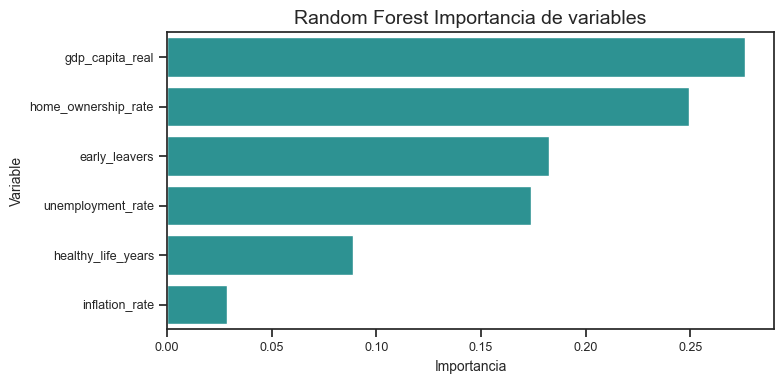

In [26]:
#Importancia de variables
imp_df = pd.DataFrame(importancias).reset_index()
imp_df.columns = ["variable", "importancia"]

plt.figure(figsize=(8,4))

sns.barplot(data=imp_df, x="importancia", y="variable", color="#1CA3A3")

titulo = "Random Forest Importancia de variables"
plt.title(titulo, fontsize=14)
plt.xlabel("Importancia", fontsize=10)
plt.ylabel("Variable", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


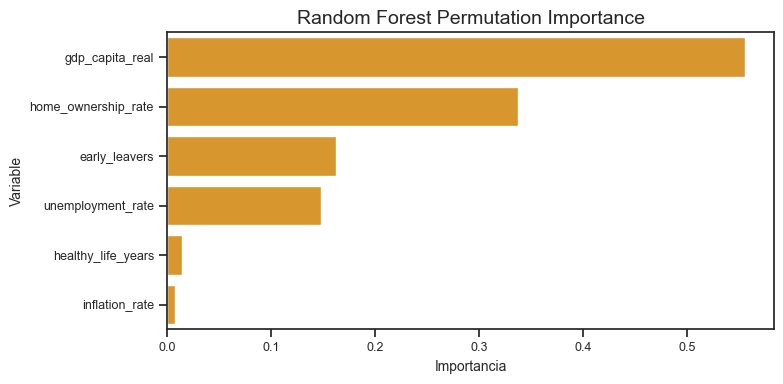

In [27]:
#Permutation Importance (más robusto que el anterior)
perm = permutation_importance(rf, x_test, y_test, n_repeats=20, random_state=42)

perm_df = pd.DataFrame({"variable": x_train.columns,
                        "importancia": perm.importances_mean
                        }).sort_values("importancia", ascending=False)

plt.figure(figsize=(8,4))

sns.barplot(data=perm_df, x="importancia", y="variable", color="#F39C12")

titulo = "Random Forest Permutation Importance"
plt.title(titulo, fontsize=14)
plt.xlabel("Importancia", fontsize=10)
plt.ylabel("Variable", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


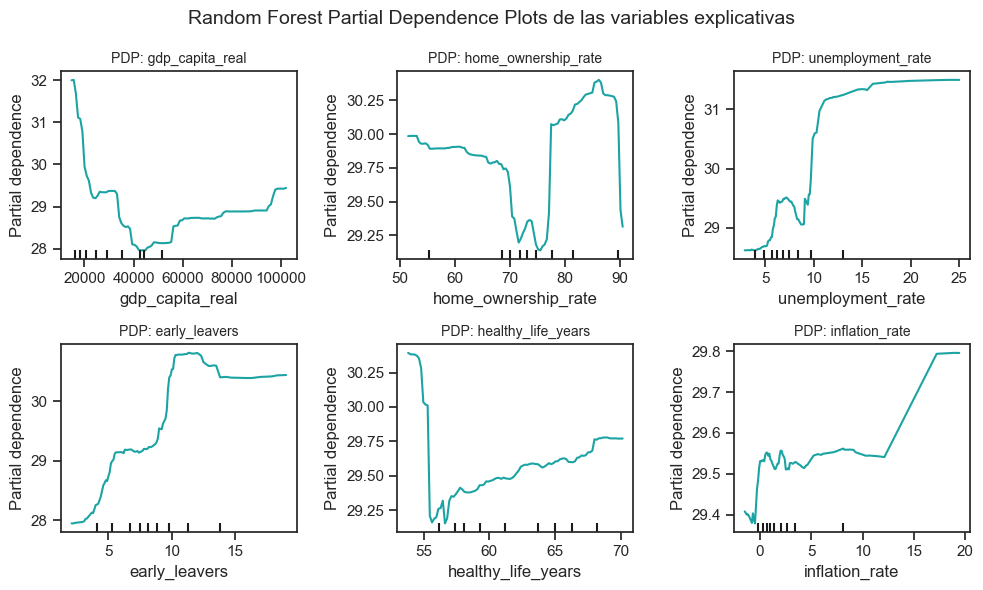

In [28]:
#Partial Dependence Plots
fig, ax = plt.subplots(2, 3, figsize=(10,6))
for i, var in enumerate(vars_exp):
    ax_i = ax[i//3, i%3]
    PartialDependenceDisplay.from_estimator(rf, x_train, [var], ax=ax_i, line_kw={"color": "#1CA3A3"}) 
    ax_i.set_title(f"PDP: {var}", fontsize=10) 
    ax_i.set_xlabel("")
    ax_i.set_ylabel("")
    ax_i.tick_params(axis='both', labelsize=9)

titulo = "Random Forest Partial Dependence Plots de las variables explicativas"
fig.suptitle(titulo, fontsize=14)

fig.tight_layout()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


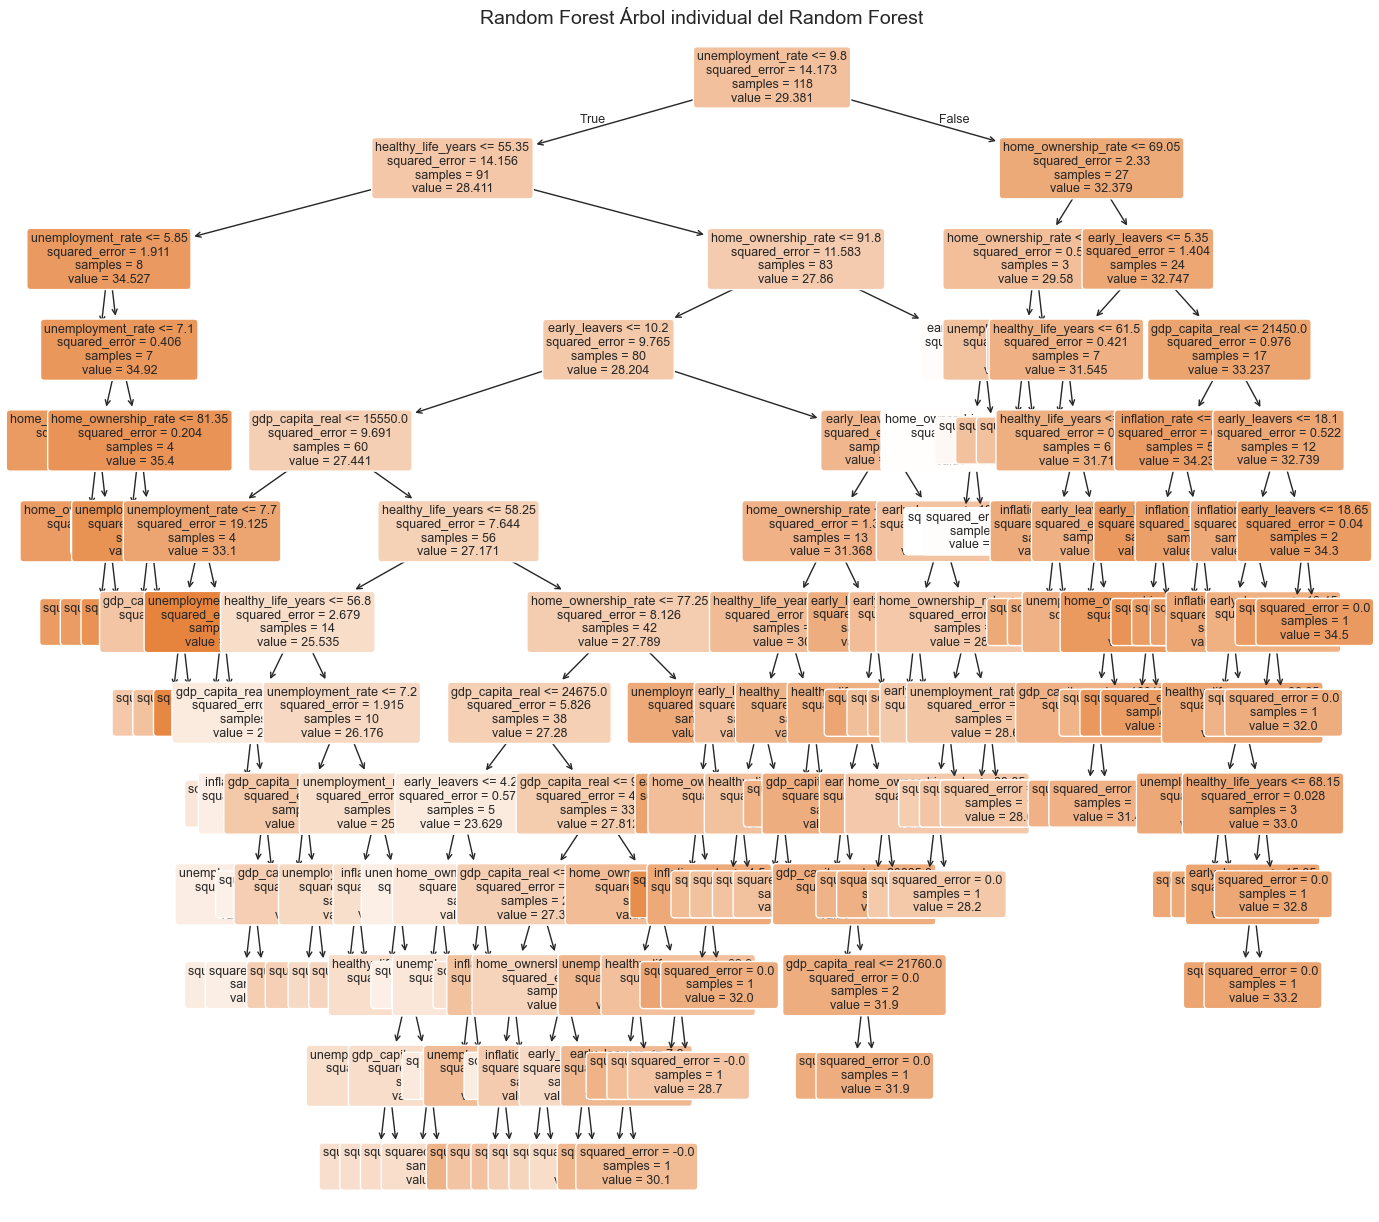

In [29]:
#Visualización de un árbol individual
plt.figure(figsize=(14,6))

plot_tree(rf.estimators_[0],
          feature_names=x_train.columns,
          filled=True,
          rounded=True,
          fontsize=9,
          ) #max_depth=3 para limitar ramas

titulo = "Random Forest Árbol individual del Random Forest"
plt.title(titulo, fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=2)
fig = plt.gcf()
guardar_grafico(fig,titulo)
plt.show()

Guardado con éxito.


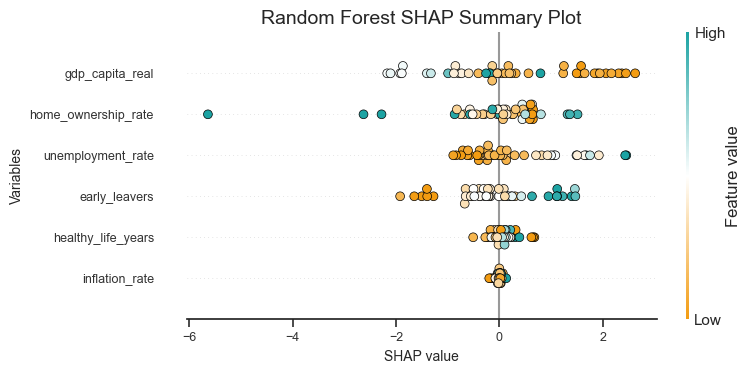

In [30]:
#SHAP Summary Plot
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_test)

plt.figure(figsize=(8,4))

shap.summary_plot(shap_values, x_test, plot_type="dot", cmap= OrWhGn, show=False)
ax = plt.gca()
for collection in ax.collections:
    collection.set_sizes([40])
    collection.set_edgecolor("black")
    collection.set_linewidth(0.5) 

titulo = "Random Forest SHAP Summary Plot"
plt.title(titulo, fontsize=14)
plt.xlabel("SHAP value", fontsize=10)
plt.ylabel("Variables", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


<Figure size 800x400 with 0 Axes>

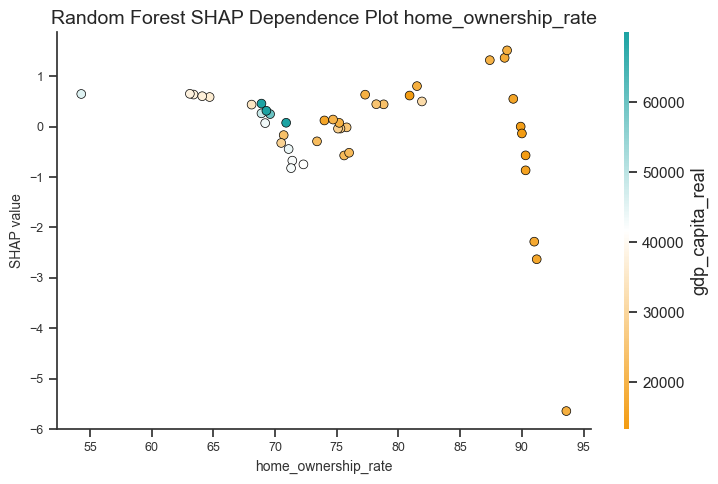

Guardado con éxito.


<Figure size 800x400 with 0 Axes>

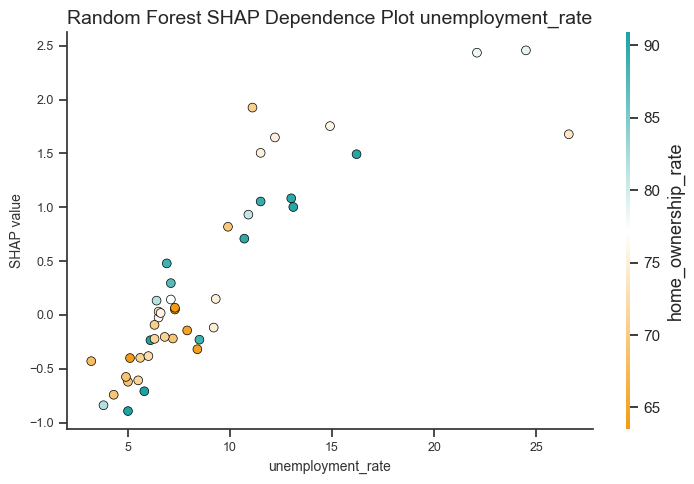

Guardado con éxito.


<Figure size 800x400 with 0 Axes>

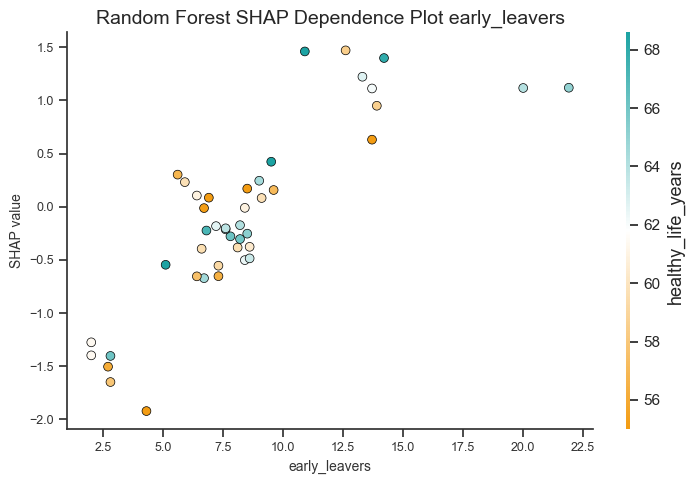

Guardado con éxito.


<Figure size 800x400 with 0 Axes>

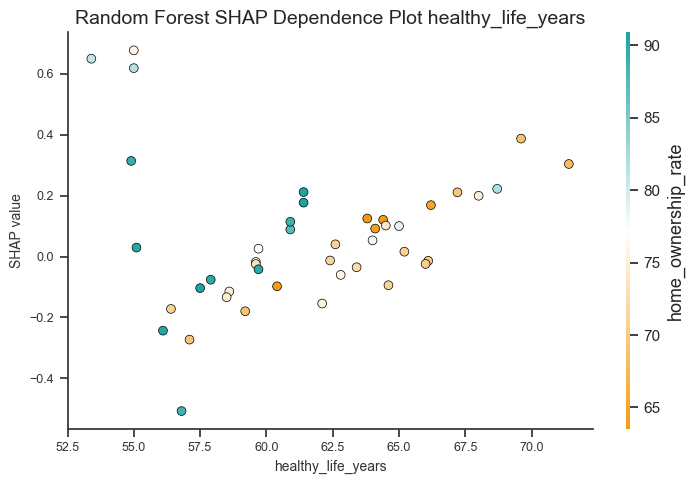

Guardado con éxito.


<Figure size 800x400 with 0 Axes>

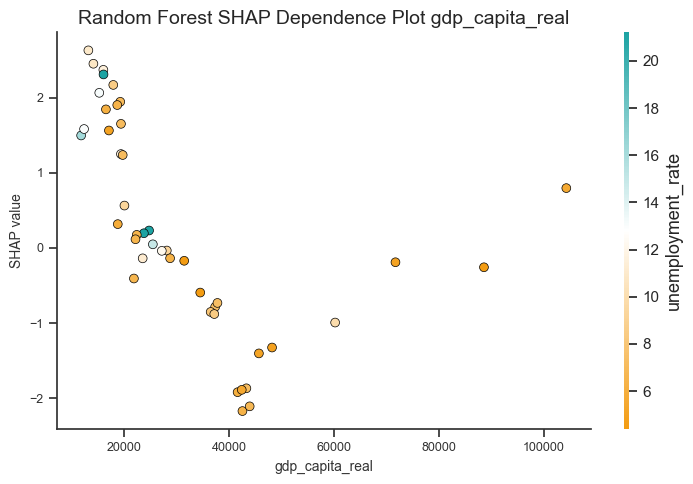

Guardado con éxito.


<Figure size 800x400 with 0 Axes>

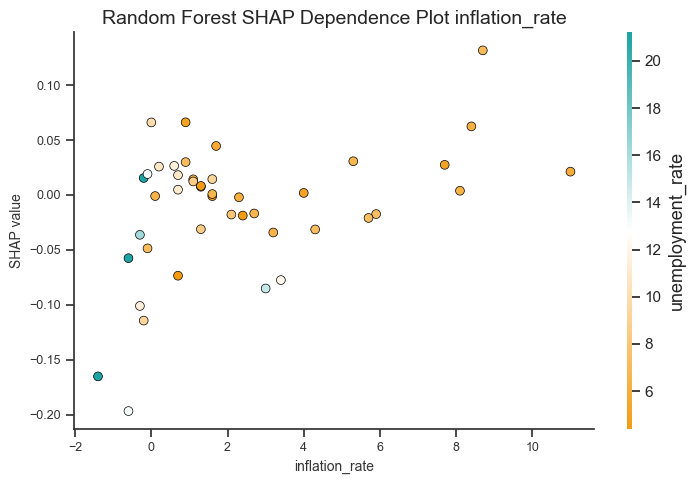

In [31]:
#SHAP Dependence Plots (uno por variable importante)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_test)

for var in x_test.columns:
    plt.figure(figsize=(8,4))
    shap.dependence_plot(var, shap_values, x_test, cmap= OrWhGn, show=False)
    ax = plt.gca()
    for collection in ax.collections:
        collection.set_sizes([40])
        collection.set_edgecolor("black")
        collection.set_linewidth(0.5)

    plt.title(f"Random Forest SHAP Dependence Plot {var}", fontsize=14)
    plt.xlabel(var, fontsize=10)
    plt.ylabel("SHAP value", fontsize=10)
    plt.tick_params(axis='both', labelsize=9)

    plt.tight_layout()
    fig = plt.gcf()
    guardar_grafico(fig, titulo)
    plt.show()

Guardado con éxito.


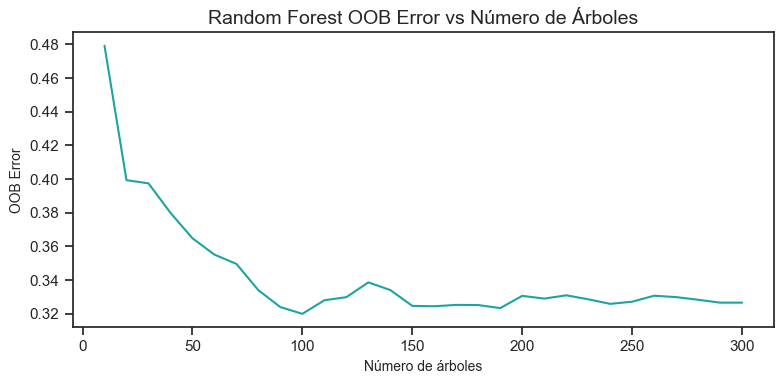

In [32]:
#OOB Error vs Número de Árboles
oob_errors = []

for n in range(10, 301, 10):
    rf_temp = RandomForestRegressor(n_estimators=n,
                                    oob_score=True,
                                    bootstrap=True,
                                    random_state=42)
    rf_temp.fit(x_train, y_train)
    oob_errors.append(1 - rf_temp.oob_score_)

plt.figure(figsize=(8,4))
plt.plot(range(10, 301, 10), oob_errors, color="#1CA3A3")

titulo = "Random Forest OOB Error vs Número de Árboles"
plt.title(titulo, fontsize=14)
plt.xlabel("Número de árboles", fontsize=10)
plt.ylabel("OOB Error", fontsize=10)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()

Guardado con éxito.


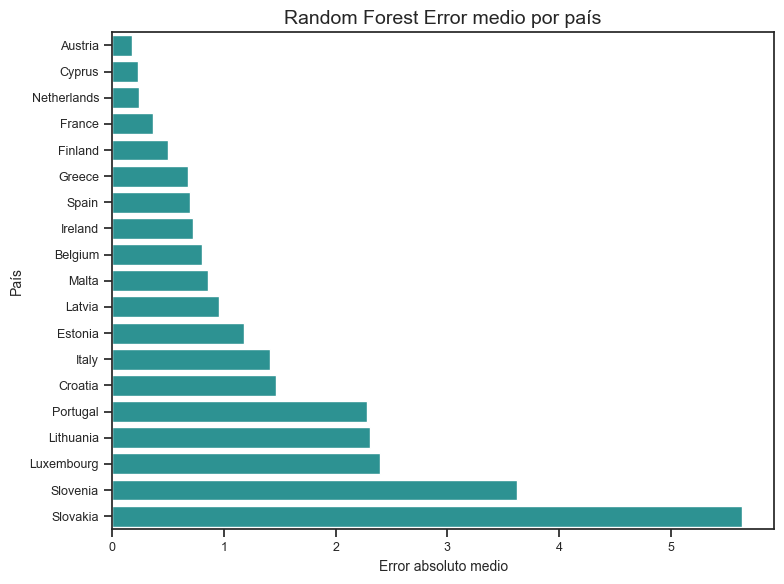

In [34]:
#Error por país
df_error = df_corr.loc[x_test.index].copy()
df_error["pred_rf"] = y_pred_rf
df_error["error"] = abs(df_error["gini"] - df_error["pred_rf"])

df_country_error = (df_error.groupby("country_name")["error"].mean().sort_values())

plt.figure(figsize=(8,6))

ax = sns.barplot(x=df_country_error.values,
                 y=df_country_error.index,
                 color="#1CA3A3")

titulo = "Random Forest Error medio por país"
plt.title(titulo, fontsize=14)
plt.xlabel("Error absoluto medio", fontsize=10)
plt.ylabel("País", fontsize=10)
plt.tick_params(axis='both', labelsize=9)

plt.tight_layout()
fig = plt.gcf()
guardar_grafico(fig, titulo)
plt.show()